In [ ]:
!pip install -q transformers accelerate bitsandbytes datasets huggingface_hub torch tqdm pandas scipy requests matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Dataset

In [ ]:
import requests
import json
import os
import pandas as pd

# Create directories
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Download dataset
!wget -O data/counterfact.json https://rome.baulab.info/data/dsets/counterfact.json

--2025-04-21 21:09:55--  https://rome.baulab.info/data/dsets/counterfact.json
Resolving rome.baulab.info (rome.baulab.info)... 35.232.255.106
Connecting to rome.baulab.info (rome.baulab.info)|35.232.255.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45108470 (43M) [application/json]
Saving to: ‘data/counterfact.json’

data/counterfact.js 100%[===================>]  43.02M   138MB/s    in 0.3s    

2025-04-21 21:09:56 (138 MB/s) - ‘data/counterfact.json’ saved [45108470/45108470]



## Load Dataset

In [ ]:
with open('data/counterfact.json', 'r') as f:
    counterfact_data = json.load(f)

## Examine Structure

In [ ]:
print(f"Dataset loaded. It contains {len(counterfact_data)} items.")

Dataset loaded. It contains 21919 items.


In [ ]:
print("\nEXAMINING FIRST ITEM STRUCTURE:")
import pprint
pprint.pprint(counterfact_data[0])


EXAMINING FIRST ITEM STRUCTURE:
{'attribute_prompts': ['J.\xa0R.\xa0R. Tolkien is a native speaker of',
                       'The mother tongue of Douglas Adams is',
                       'The mother tongue of Paul McCartney is',
                       'Elvis Presley is a native speaker of',
                       'Barack Obama, speaker of',
                       'Douglas Adams, speaker of',
                       'Meryl Streep, a native',
                       'George Orwell spoke the language',
                       'George Washington, a native',
                       'Michael Jackson, a native'],
 'case_id': 0,
 'generation_prompts': ["Danielle Darrieux's mother tongue is",
                        'Where Danielle Darrieux is from, people speak the '
                        'language of',
                        "Danielle Darrieux's mother tongue is",
                        'Danielle Darrieux was born in',
                        "Danielle Darrieux's mother tongue is",
     

## Check if all items have same structure

In [ ]:
print("\nCHECKING DATASET CONSISTENCY:")
keys_per_item = [set(item.keys()) for item in counterfact_data[:100]]  # Check first 100
all_same = all(keys == keys_per_item[0] for keys in keys_per_item)
print(f"All items have the same top-level keys: {all_same}")
if not all_same:
    key_counts = {}
    for keys in keys_per_item:
        key_tuple = tuple(sorted(keys))
        key_counts[key_tuple] = key_counts.get(key_tuple, 0) + 1
    print("Different key structures found:")
    for keys, count in key_counts.items():
        print(f"  {keys}: {count} items")


CHECKING DATASET CONSISTENCY:
All items have the same top-level keys: True


## Structure of 'requested_rewrite'

In [ ]:
rewrite_keys = [set(item['requested_rewrite'].keys()) for item in counterfact_data[:100]]
all_same_rewrite = all(keys == rewrite_keys[0] for keys in rewrite_keys)
print(f"All 'requested_rewrite' have the same keys: {all_same_rewrite}")
if not all_same_rewrite:
    rewrite_key_counts = {}
    for keys in rewrite_keys:
        key_tuple = tuple(sorted(keys))
        rewrite_key_counts[key_tuple] = rewrite_key_counts.get(key_tuple, 0) + 1
    print("Different 'requested_rewrite' structures found:")
    for keys, count in rewrite_key_counts.items():
        print(f"  {keys}: {count} items")

All 'requested_rewrite' have the same keys: True


## Test Sample and Prompt Format Verification

In [ ]:
test_samples = counterfact_data[:5]

In [ ]:
test_samples[0]

{'case_id': 0,
 'pararel_idx': 2796,
 'requested_rewrite': {'prompt': 'The mother tongue of {} is',
  'relation_id': 'P103',
  'target_new': {'str': 'English', 'id': 'Q1860'},
  'target_true': {'str': 'French', 'id': 'Q150'},
  'subject': 'Danielle Darrieux'},
 'paraphrase_prompts': ['Shayna does this and Yossel goes still and dies. Danielle Darrieux, a native',
  'An album was recorded for Capitol Nashville but never released. Danielle Darrieux spoke the language'],
 'neighborhood_prompts': ['The mother tongue of Léon Blum is',
  'The native language of Montesquieu is',
  'François Bayrou, a native',
  'The native language of Raymond Barre is',
  'Michel Rocard is a native speaker of',
  'Jacques Chaban-Delmas is a native speaker of',
  'The native language of François Bayrou is',
  'Maurice Genevoix, speaker of',
  'The mother tongue of François Bayrou is',
  'Melchior de Vogüé, speaker of'],
 'attribute_prompts': ['J.\xa0R.\xa0R. Tolkien is a native speaker of',
  'The mother tongue

In [ ]:
def format_prompt(item):
    """
    Format a prompt for the Mixtral model based on a Counterfact dataset item.
    """
    # Get the original prompt from the dataset
    prompt = item['requested_rewrite']['prompt'].replace("{}", item['requested_rewrite']['subject'])

    # Return the formatted prompt
    return prompt

In [ ]:
# Check the prompts for our test samples
print("\nTEST PROMPTS:")
for i, item in enumerate(test_samples):
    prompt = format_prompt(item)
    print(f"\nTest Prompt {i+1}:")
    print(f"Subject: {item['requested_rewrite']['subject']}")
    if 'relation_id' in item['requested_rewrite']:
        print(f"Relation: {item['requested_rewrite']['relation_id']}")
    print(f"Target True: {item['requested_rewrite']['target_true']['str']}")
    if 'target_false' in item['requested_rewrite']:
        if isinstance(item['requested_rewrite']['target_false'], dict) and 'str' in item['requested_rewrite']['target_false']:
            print(f"Target False: {item['requested_rewrite']['target_false']['str']}")
    print(f"Prompt: {prompt}")


TEST PROMPTS:

Test Prompt 1:
Subject: Danielle Darrieux
Relation: P103
Target True: French
Prompt: The mother tongue of Danielle Darrieux is

Test Prompt 2:
Subject: Edwin of Northumbria
Relation: P140
Target True: Christianity
Prompt: The official religion of Edwin of Northumbria is

Test Prompt 3:
Subject: Toko Yasuda
Relation: P1303
Target True: guitar
Prompt: Toko Yasuda, the

Test Prompt 4:
Subject: Autonomous University of Madrid
Relation: P17
Target True: Spain
Prompt: Autonomous University of Madrid, which is located in

Test Prompt 5:
Subject: Lyon
Relation: P190
Target True: Beirut
Prompt: What is the twin city of Lyon? It is


# Model Setup

In [ ]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import login

In [ ]:
# Clean memory
gc.collect()
torch.cuda.empty_cache()

### HuggingFace Authentication

In [ ]:
print("Please enter your HuggingFace token when prompted:")
login()

Please enter your HuggingFace token when prompted:


## Mixtral 8x7B 4 bit quantized

In [ ]:
print("Loading model...")
model_id = "mistralai/Mixtral-8x7B-Instruct-v0.1"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Load model with error handling
try:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        load_in_4bit=True,
        torch_dtype=torch.bfloat16,
    )
    print("Model loaded successfully")
except Exception as e:
    print(f"Error loading model: {e}")
    raise

Loading model...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors.index.json:   0%|          | 0.00/92.7k [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

model-00004-of-00019.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

...

model-00018-of-00019.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00019-of-00019.safetensors:   0%|          | 0.00/4.22G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/19 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded successfully


## Response Generation Function

In [ ]:
def generate_response(prompt, max_new_tokens=128):
    """
    Generate a response from the Mixtral model using the chat template.

    Args:
        prompt: The prompt to use
        max_new_tokens: Maximum number of tokens to generate

    Returns:
        The generated response
    """
    # Format according to Mixtral's chat template
    formatted_prompt = f"<s>[INST] You will be given an incomplete part of a sentence. Only provide one or two words to complete it. Do not give any explanation and answer in short. \
                        Here is the sentence: {prompt} [/INST]"

    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,  # Low temperature for more deterministic outputs
            do_sample=False,   # Greedy decoding
            pad_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only the model's response (remove the prompt)
    response = full_output[len(tokenizer.decode(inputs.input_ids[0], skip_special_tokens=True)):].strip()

    return response

### Testing Response Generation

In [ ]:
print("\nTESTING MODEL GENERATION:")
for i, item in enumerate(test_samples):
    prompt = format_prompt(item)
    print(f"\nTest {i+1}:")
    print(f"Prompt: {prompt}")
    response = generate_response(prompt)
    print(f"Response: {response[:200]}..." if len(response) > 200 else response)

    # Check if true/false targets are in the response
    target_true = item['requested_rewrite']['target_true']['str']
    target_false = item['requested_rewrite'].get('target_false', {}).get('str', '')

    contains_true = target_true.lower() in response.lower()
    contains_false = target_false.lower() in response.lower() if target_false else False

    print(f"Contains true target '{target_true}': {contains_true}")
    print(f"Contains false target '{target_false}': {contains_false}" if target_false else "No false target specified")


TESTING MODEL GENERATION:

Test 1:
Prompt: The mother tongue of Danielle Darrieux is
French.

(Note: Danielle Darrieux is a French film actress and singer.)
Contains true target 'French': True
No false target specified

Test 2:
Prompt: The official religion of Edwin of Northumbria is
Christianity. (Edwin of Northumbria, who ruled from 616 to 633 AD, officially converted to Christianity during his reign.)
Contains true target 'Christianity': True
No false target specified

Test 3:
Prompt: Toko Yasuda, the
...guitarist of the band Cornelius.
Contains true target 'guitar': True
No false target specified

Test 4:
Prompt: Autonomous University of Madrid, which is located in
Spain.

(Note: The Autonomous University of Madrid is a public university located in Madrid, Spain.)
Contains true target 'Spain': True
No false target specified

Test 5:
Prompt: What is the twin city of Lyon? It is
Response: Paris. (However, I must note that this is not a common way to refer to cities; Lyon does not ha

## Evaluation on Counterfact Dataset

In [ ]:
import time
from tqdm.auto import tqdm

In [ ]:
def evaluate_counterfact(dataset, num_samples=None, save_every=10):
    """
    Evaluate the Mixtral model on the Counterfact dataset.

    Args:
        dataset: The dataset to evaluate
        num_samples: Number of samples to evaluate (None for all)
        save_every: Save intermediate results every n samples

    Returns:
        DataFrame containing the evaluation results
    """
    results = []
    errors = 0

    if num_samples is None:
        samples = dataset
    else:
        # Use a subset for testing
        samples = dataset[:min(num_samples, len(dataset))]

    start_time = time.time()

    for idx, item in enumerate(tqdm(samples)):
        try:
            # Format the prompt
            prompt = format_prompt(item)

            # Skip if prompt is empty or None
            if not prompt:
                print(f"Skipping item {idx} due to empty prompt")
                errors += 1
                continue

            # Extract targets
            target_true = item['requested_rewrite']['target_true']['str']

            # Some items might not have target_false
            if 'target_false' in item['requested_rewrite'] and isinstance(item['requested_rewrite']['target_false'], dict):
                target_false = item['requested_rewrite']['target_false'].get('str', '')
            else:
                target_false = ''

            # Skip if true target is empty
            if not target_true:
                print(f"Skipping item {idx} due to empty true target")
                errors += 1
                continue

            # Generate response
            response = generate_response(prompt, max_new_tokens=100)

            # Skip if response generation failed
            if not response:
                print(f"Skipping item {idx} due to empty response")
                errors += 1
                continue

            # Check if the response contains the true or false target
            contains_true = target_true.lower() in response.lower()
            contains_false = target_false.lower() in response.lower() if target_false else False

            # Store result
            result = {
                'subject': item['requested_rewrite']['subject'],
                'relation': item['requested_rewrite'].get('relation_id', ''),
                'target_true': target_true,
                'target_false': target_false,
                'prompt': prompt,
                'model_response': response,
                'contains_true': contains_true,
                'contains_false': contains_false,
            }

            # Determine correctness
            if contains_true and not contains_false:
                result['correct'] = True
            elif contains_false and not contains_true:
                result['correct'] = False
            else:
                # If neither or both are present, mark as ambiguous
                result['correct'] = None

            results.append(result)

            # Save intermediate results
            if (idx + 1) % save_every == 0:
                pd.DataFrame(results).to_csv(f'results/mixtral_counterfact_results_intermediate_{idx+1}.csv', index=False)
                elapsed_time = time.time() - start_time
                avg_time_per_sample = elapsed_time / (idx + 1)
                estimated_total_time = avg_time_per_sample * len(samples)
                remaining_time = estimated_total_time - elapsed_time

                print(f"Processed {idx+1}/{len(samples)} samples")
                print(f"Elapsed time: {elapsed_time/60:.2f} minutes")
                print(f"Estimated time remaining: {remaining_time/60:.2f} minutes")
                print(f"Errors so far: {errors}")

                # Clean memory periodically
                gc.collect()
                torch.cuda.empty_cache()

        except Exception as e:
            errors += 1
            print(f"Error processing item {idx}: {e}")
            # Continue with the next item
            continue

    if errors > 0:
        print(f"Completed with {errors} errors out of {len(samples)} samples.")

    return pd.DataFrame(results)

### Small eval to verify

In [ ]:
# Run a small evaluation first to verify
small_eval_size = 10
print(f"Running small evaluation on {small_eval_size} samples...")
small_results = evaluate_counterfact(counterfact_data, num_samples=small_eval_size)

# Save the small evaluation results
small_results.to_csv('results/mixtral_counterfact_small_eval.csv', index=False)

# Calculate metrics
total_samples = len(small_results)
correct_samples = sum(x is True for x in small_results['correct'])
incorrect_samples = sum(x is False for x in small_results['correct'])
ambiguous_samples = sum(x is None for x in small_results['correct'])

# Print metrics
print(f"\n===== SMALL EVALUATION METRICS ({total_samples} samples) =====")
print(f"Correct: {correct_samples} ({correct_samples/total_samples:.2%})")
print(f"Incorrect: {incorrect_samples} ({incorrect_samples/total_samples:.2%})")
print(f"Ambiguous: {ambiguous_samples} ({ambiguous_samples/total_samples:.2%})")

Running small evaluation on 10 samples...


  0%|          | 0/10 [00:00<?, ?it/s]

Processed 10/10 samples
Elapsed time: 0.90 minutes
Estimated time remaining: 0.00 minutes
Errors so far: 0

===== SMALL EVALUATION METRICS (10 samples) =====
Correct: 7 (70.00%)
Incorrect: 0 (0.00%)
Ambiguous: 3 (30.00%)


## Full Evaluation on 200 examples of Counterfact

In [ ]:
# Run the full evaluation
print("\nRunning full evaluation...")
eval_size = 200  # Adjust based on your resources/time
full_results = evaluate_counterfact(counterfact_data, num_samples=eval_size)

# Save the full results
full_results.to_csv('results/mixtral_counterfact_full_results.csv', index=False)

# Calculate metrics
total_samples = len(full_results)
correct_samples = sum(x is True for x in full_results['correct'])
incorrect_samples = sum(x is False for x in full_results['correct'])
ambiguous_samples = sum(x is None for x in full_results['correct'])

accuracy = correct_samples / total_samples
error_rate = incorrect_samples / total_samples
ambiguity_rate = ambiguous_samples / total_samples

true_positive_rate = full_results['contains_true'].sum() / total_samples
false_positive_rate = full_results['contains_false'].sum() / total_samples

print(f"\n===== EVALUATION METRICS =====")
print(f"Model: Mixtral-8x7B-Instruct-v0.1 (4-bit quantized)")
print(f"Dataset: Counterfact (subset of {total_samples} samples)")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Ambiguity Rate: {ambiguity_rate:.4f}")
print(f"True Target Mention Rate: {true_positive_rate:.4f}")
print(f"False Target Mention Rate: {false_positive_rate:.4f}")

# Generate a confusion matrix-like analysis
print("\n===== DETAILED ANALYSIS =====")
print(f"Correctly mentioned true target only: {correct_samples} ({correct_samples/total_samples:.2%})")
print(f"Incorrectly mentioned false target only: {incorrect_samples} ({incorrect_samples/total_samples:.2%})")
print(f"Ambiguous (mentioned both or neither): {ambiguous_samples} ({ambiguous_samples/total_samples:.2%})")

# Check performance by relation type
relation_performance = full_results.groupby('relation').apply(
    lambda group: pd.Series({
        'count': len(group),
        'correct': sum(x is True for x in group['correct'])/len(group) if len(group) > 0 else 0,
        'incorrect': sum(x is False for x in group['correct'])/len(group) if len(group) > 0 else 0,
        'ambiguous': sum(x is None for x in group['correct'])/len(group) if len(group) > 0 else 0
    })
).sort_values('count', ascending=False)

print("\n===== PERFORMANCE BY RELATION TYPE =====")
print(relation_performance.head(10))  # Show top 10 most common relations


Running full evaluation...


  0%|          | 0/200 [00:00<?, ?it/s]

Processed 10/200 samples
Elapsed time: 0.90 minutes
Estimated time remaining: 17.13 minutes
Errors so far: 0
Processed 20/200 samples
Elapsed time: 1.54 minutes
Estimated time remaining: 13.87 minutes
Errors so far: 0
Processed 30/200 samples
Elapsed time: 2.35 minutes
Estimated time remaining: 13.30 minutes
Errors so far: 0
Processed 40/200 samples
Elapsed time: 3.20 minutes
Estimated time remaining: 12.81 minutes
Errors so far: 0
Processed 50/200 samples
Elapsed time: 4.13 minutes
Estimated time remaining: 12.38 minutes
Errors so far: 0
Processed 60/200 samples
Elapsed time: 5.07 minutes
Estimated time remaining: 11.82 minutes
Errors so far: 0
Processed 70/200 samples
Elapsed time: 5.67 minutes
Estimated time remaining: 10.53 minutes
Errors so far: 0
Processed 80/200 samples
Elapsed time: 6.69 minutes
Estimated time remaining: 10.04 minutes
Errors so far: 0
Skipping item 81 due to empty response
Processed 90/200 samples
Elapsed time: 7.31 minutes
Estimated time remaining: 8.93 minute

<ipython-input-29-ab3a3129b8b3>:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  relation_performance = full_results.groupby('relation').apply(


## Visualizations

<ipython-input-30-1b9cd7f49988>:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_accuracy = full_results.groupby('length_bin').apply(
<ipython-input-30-1b9cd7f49988>:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  length_accuracy = full_results.groupby('length_bin').apply(


Visualizations saved to results/mixtral_counterfact_analysis.png


<ipython-input-30-1b9cd7f49988>:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes2[1, 0].boxplot(data_to_plot, labels=labels)


Additional visualizations saved to results/mixtral_counterfact_additional_analysis.png


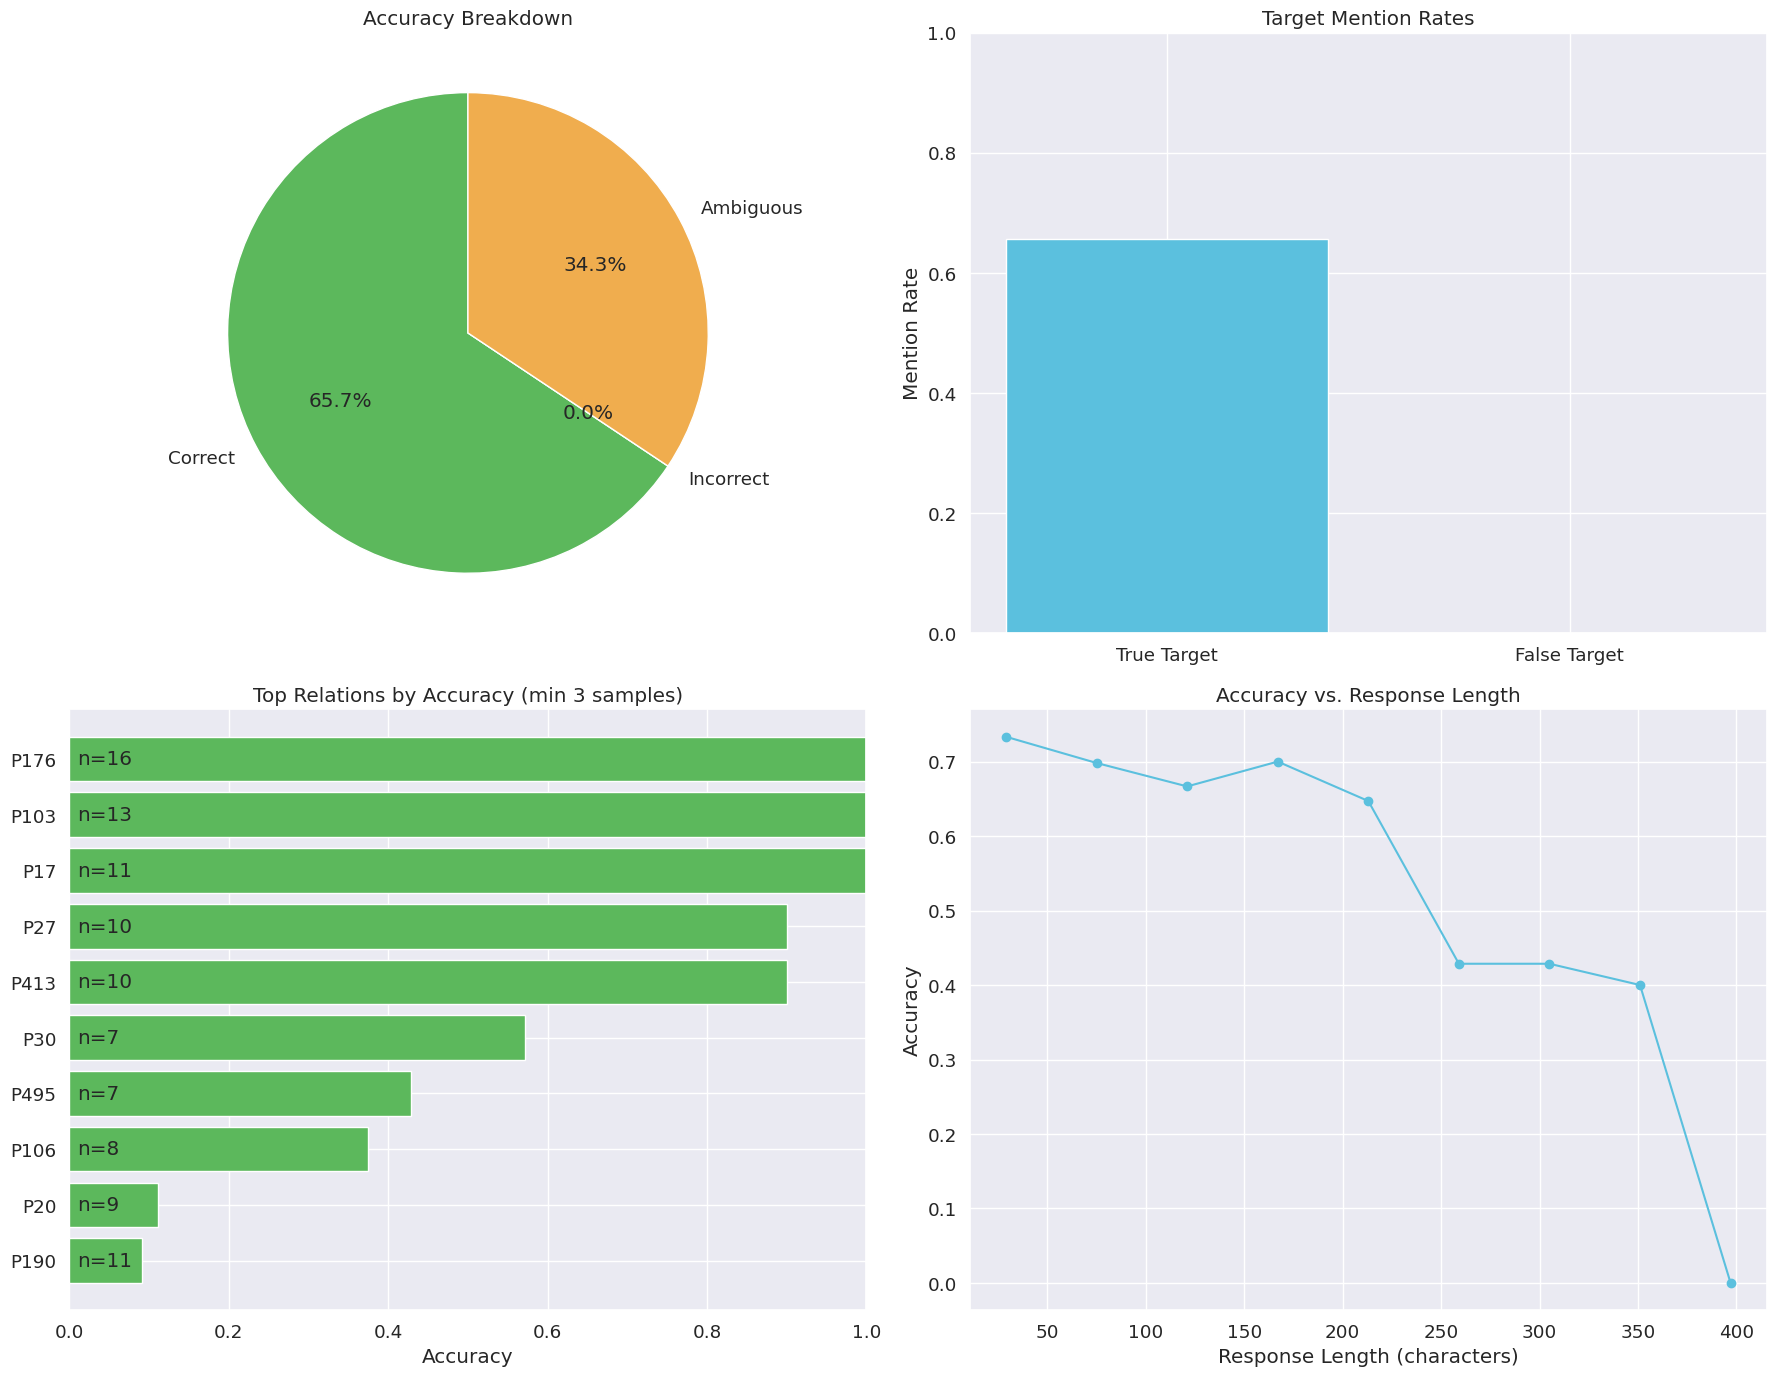

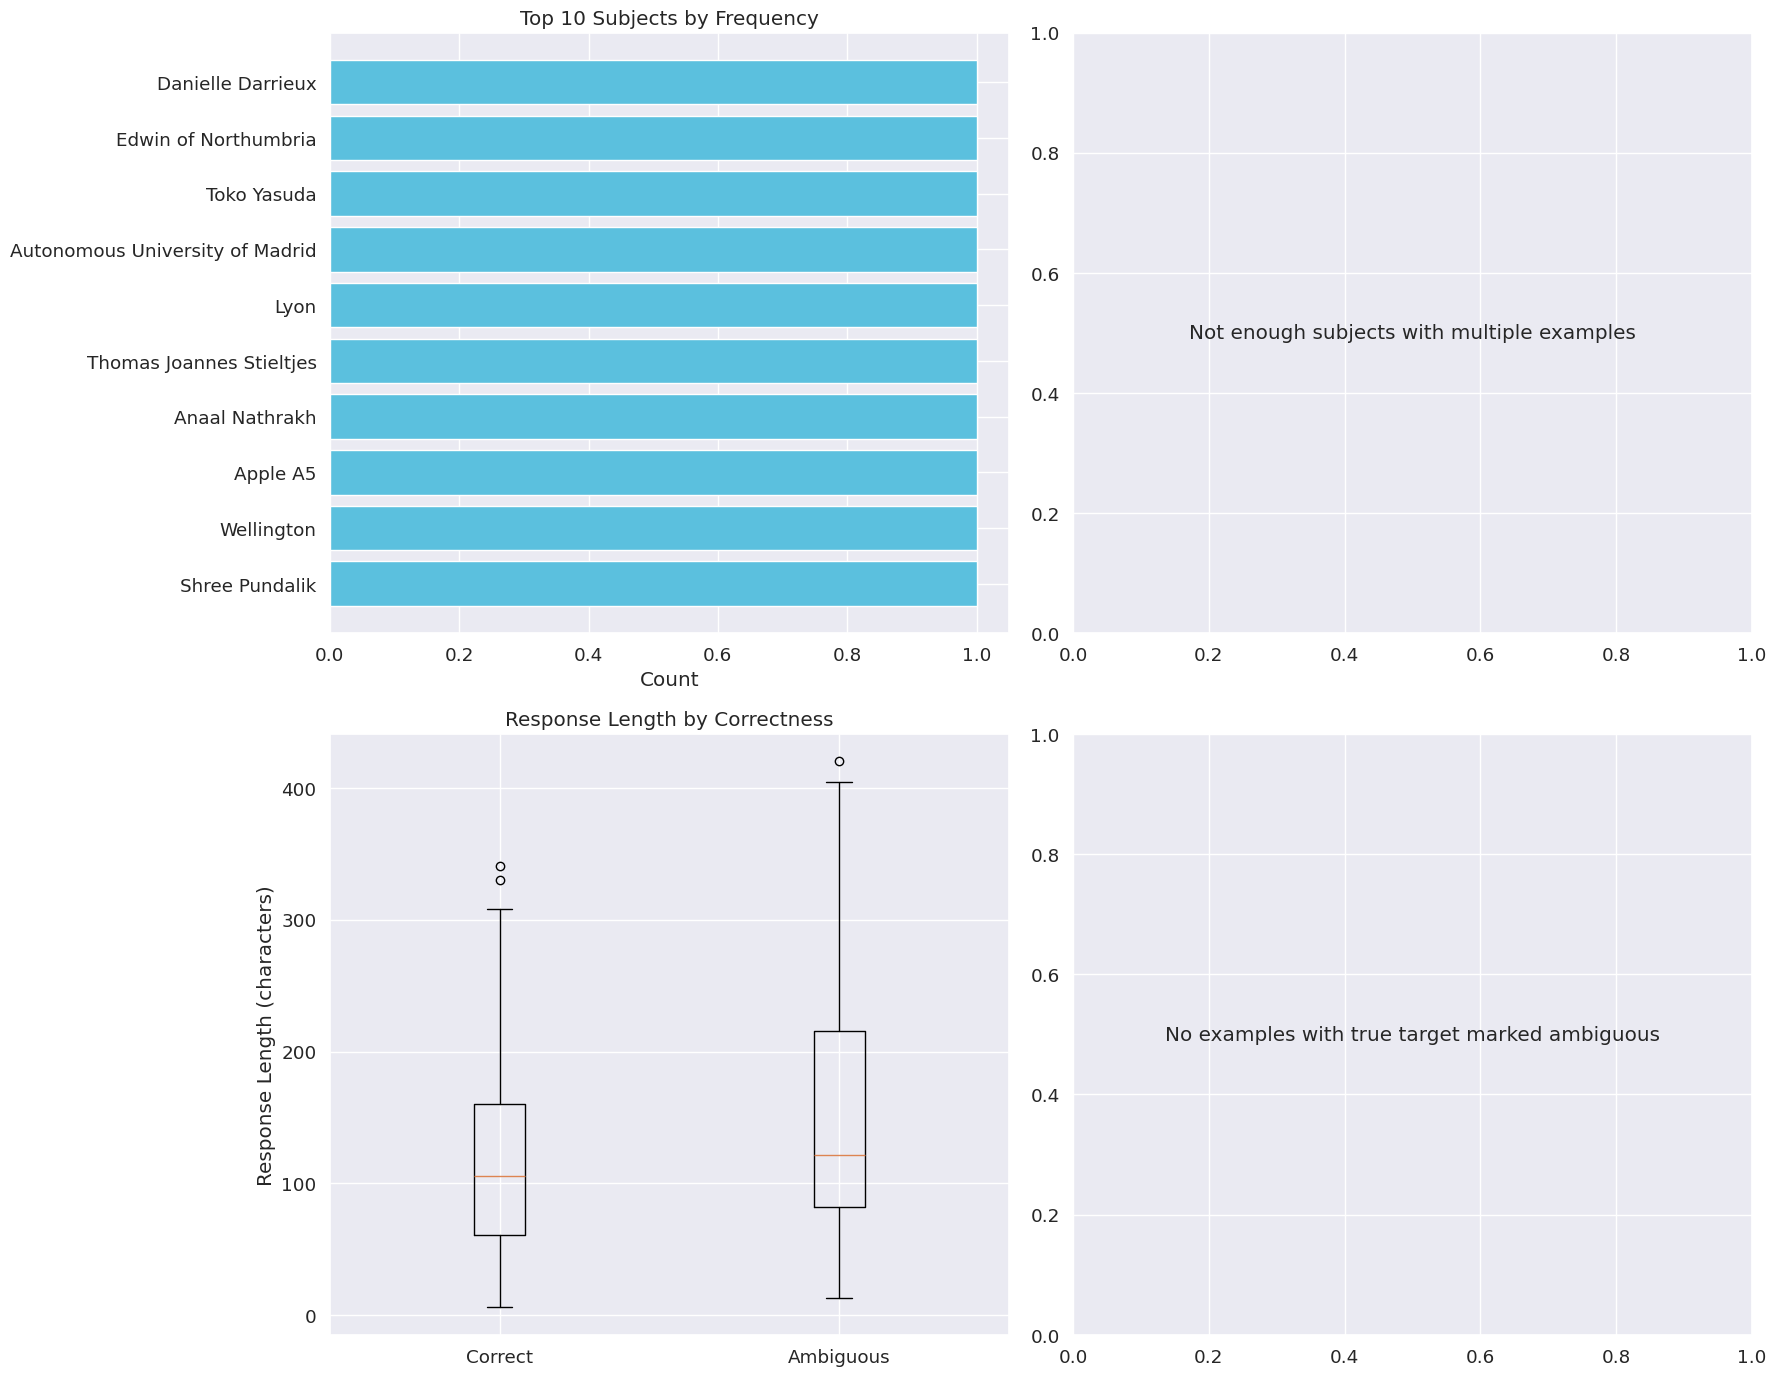

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Accuracy Pie Chart
labels = ['Correct', 'Incorrect', 'Ambiguous']
sizes = [correct_samples, incorrect_samples, ambiguous_samples]
colors = ['#5cb85c', '#d9534f', '#f0ad4e']

axes[0, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Accuracy Breakdown')

# Plot 2: True vs False Target Mentions
mentions = ['True Target', 'False Target']
mention_rates = [true_positive_rate, false_positive_rate]
axes[0, 1].bar(mentions, mention_rates, color=['#5bc0de', '#d9534f'])
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('Target Mention Rates')
axes[0, 1].set_ylabel('Mention Rate')

# Plot 3: Top 10 relations by accuracy
if len(relation_performance) >= 5:
    # Filter to relations with at least 3 examples for more reliable statistics
    common_relations = relation_performance[relation_performance['count'] >= 3].head(10)

    if not common_relations.empty:
        common_relations = common_relations.sort_values('correct')
        axes[1, 0].barh(common_relations.index, common_relations['correct'], color='#5cb85c')
        axes[1, 0].set_title('Top Relations by Accuracy (min 3 samples)')
        axes[1, 0].set_xlabel('Accuracy')
        axes[1, 0].set_xlim(0, 1)
        # Add sample count to labels
        for i, (idx, row) in enumerate(common_relations.iterrows()):
            axes[1, 0].text(0.01, i, f"n={int(row['count'])}", va='center')
    else:
        axes[1, 0].text(0.5, 0.5, 'Not enough data for relation analysis',
                      horizontalalignment='center', verticalalignment='center')
else:
    axes[1, 0].text(0.5, 0.5, 'Not enough data for relation analysis',
                  horizontalalignment='center', verticalalignment='center')

# Plot 4: Response length vs correctness
full_results['response_length'] = full_results['model_response'].apply(len)
length_bins = np.linspace(min(full_results['response_length']),
                         max(full_results['response_length']),
                         10)
full_results['length_bin'] = pd.cut(full_results['response_length'], bins=length_bins)

# Group by length bin and calculate correct percentage
length_accuracy = full_results.groupby('length_bin').apply(
    lambda x: sum(y is True for y in x['correct']) / len(x) if len(x) > 0 else 0
).reset_index()
length_accuracy.columns = ['length_bin', 'accuracy']

# Extract the midpoint of each bin for plotting
length_accuracy['bin_midpoint'] = length_accuracy['length_bin'].apply(lambda x: x.mid)

# Plot accuracy vs response length
axes[1, 1].plot(length_accuracy['bin_midpoint'], length_accuracy['accuracy'], 'o-', color='#5bc0de')
axes[1, 1].set_title('Accuracy vs. Response Length')
axes[1, 1].set_xlabel('Response Length (characters)')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('results/mixtral_counterfact_analysis.png', dpi=300)
print("Visualizations saved to results/mixtral_counterfact_analysis.png")

# Create additional visualizations for more insights
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Top 10 subjects by frequency
subject_counts = full_results['subject'].value_counts().head(10)
axes2[0, 0].barh(subject_counts.index[::-1], subject_counts.values[::-1], color='#5bc0de')
axes2[0, 0].set_title('Top 10 Subjects by Frequency')
axes2[0, 0].set_xlabel('Count')

# Plot 2: Performance on subjects with multiple examples
subjects_with_multiple = full_results['subject'].value_counts()
subjects_with_multiple = subjects_with_multiple[subjects_with_multiple >= 3].index
if len(subjects_with_multiple) > 0:
    multiple_examples = full_results[full_results['subject'].isin(subjects_with_multiple)]
    subject_performance = multiple_examples.groupby('subject').apply(
        lambda x: sum(y is True for y in x['correct']) / len(x)
    ).sort_values(ascending=False).head(10)

    axes2[0, 1].bar(subject_performance.index, subject_performance.values, color='#5cb85c')
    axes2[0, 1].set_title('Top 10 Subjects by Accuracy (min 3 examples)')
    axes2[0, 1].set_ylabel('Accuracy')
    axes2[0, 1].set_ylim(0, 1)
    axes2[0, 1].tick_params(axis='x', rotation=45)
else:
    axes2[0, 1].text(0.5, 0.5, 'Not enough subjects with multiple examples',
                  horizontalalignment='center', verticalalignment='center')

# Plot 3: Examples of correct vs incorrect responses (length comparison)
correct_lengths = [len(resp) for resp, corr in zip(full_results['model_response'], full_results['correct']) if corr is True]
incorrect_lengths = [len(resp) for resp, corr in zip(full_results['model_response'], full_results['correct']) if corr is False]
ambiguous_lengths = [len(resp) for resp, corr in zip(full_results['model_response'], full_results['correct']) if corr is None]

if correct_lengths and (incorrect_lengths or ambiguous_lengths):
    data_to_plot = []
    labels = []

    if correct_lengths:
        data_to_plot.append(correct_lengths)
        labels.append('Correct')
    if incorrect_lengths:
        data_to_plot.append(incorrect_lengths)
        labels.append('Incorrect')
    if ambiguous_lengths:
        data_to_plot.append(ambiguous_lengths)
        labels.append('Ambiguous')

    axes2[1, 0].boxplot(data_to_plot, labels=labels)
    axes2[1, 0].set_title('Response Length by Correctness')
    axes2[1, 0].set_ylabel('Response Length (characters)')
else:
    axes2[1, 0].text(0.5, 0.5, 'Not enough data for comparison',
                  horizontalalignment='center', verticalalignment='center')

# Plot 4: Examples where true target is present but still marked ambiguous
ambiguous_with_true = full_results[(full_results['correct'].isna()) & (full_results['contains_true'] == True)]
if len(ambiguous_with_true) > 0:
    # Count occurrences by relation
    relation_counts = ambiguous_with_true['relation'].value_counts().head(10)
    axes2[1, 1].barh(relation_counts.index[::-1], relation_counts.values[::-1], color='#f0ad4e')
    axes2[1, 1].set_title('Relations with True Target but Marked Ambiguous')
    axes2[1, 1].set_xlabel('Count')
else:
    axes2[1, 1].text(0.5, 0.5, 'No examples with true target marked ambiguous',
                  horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('results/mixtral_counterfact_additional_analysis.png', dpi=300)
print("Additional visualizations saved to results/mixtral_counterfact_additional_analysis.png")